In [1]:
import os
import pickle
import sys
import numpy as np

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.models.machines import ieee_machine2_trained_neural_flux
from current_setpoints.models.forward_model import ForwardModel, Fault
from current_setpoints.optimization.dynamic_optimizer import IndependentOptimizer
from current_setpoints.optimization.grid import calculate_grid
from current_setpoints.optimization.data import grid_to_data
from current_setpoints.utils.plotting import plot_grid_segments

In [2]:
CURR_MAX = 30.0
VOLT_MAX = 13.0
OMEGA_MAX = 1800.0  # mechanical RPM

SLSQP_OPTS = {"disp": False, "ftol": 1e-8, "maxiter": 500}
N_GRID = 60  # multiple of 5 -- avoids the phase-aliasing artifact confirmed in FAULT_TOLERANT.md

GRID_OPTS = {"n_torq": 15, "n_omega": 15, "torq_min": 0.0, "omega_min": 0.0, "omega_max": OMEGA_MAX}

SCENARIOS = {
    "healthy": (),
    "one_fault": (0,),
    "two_adjacent": (0, 1),
    "two_nonadjacent": (0, 2),
}

In [3]:
grids = {}
for name, open_phases in SCENARIOS.items():
    pkl_path = os.path.join(data_dir, f"fault_map_{name}.pkl")

    if os.path.isfile(pkl_path):
        with open(pkl_path, "rb") as f:
            grids[name] = pickle.load(f)
        continue

    drive = ieee_machine2_trained_neural_flux(curr_max=CURR_MAX, volt_max=VOLT_MAX)
    fwd = ForwardModel(drive, n_theta=700, fault=Fault(open_phases))
    optimizer = IndependentOptimizer(fwd, opts=SLSQP_OPTS, n_grid=N_GRID)

    grid = calculate_grid(optimizer=optimizer, fwd=fwd, opts=GRID_OPTS, mode="standard")
    with open(pkl_path, "wb") as f:
        pickle.dump(grid, f)
    grids[name] = grid

Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM

c:\Users\matas\Desktop\CurrentSetpoints_main\current_setpoints\optimization\dynamic_optimizer.py:147: RuntimeWarning: Mean of empty slice
  mean_dq = np.nanmean(curr_dq_grid, axis=0)


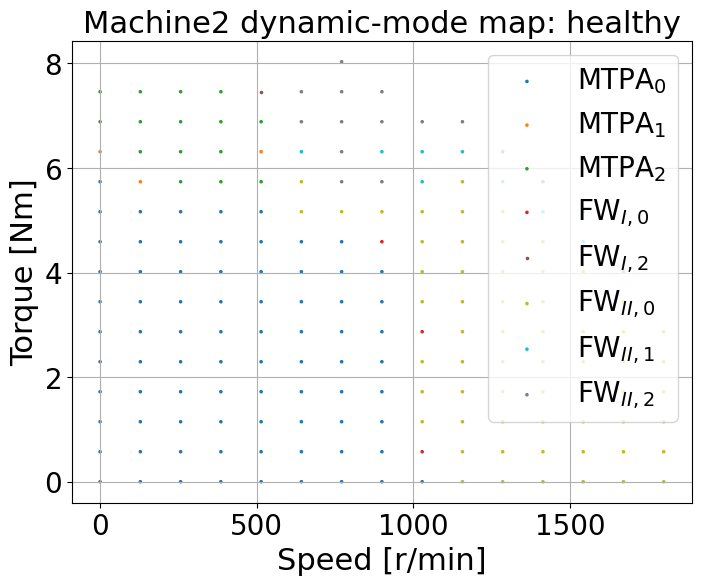

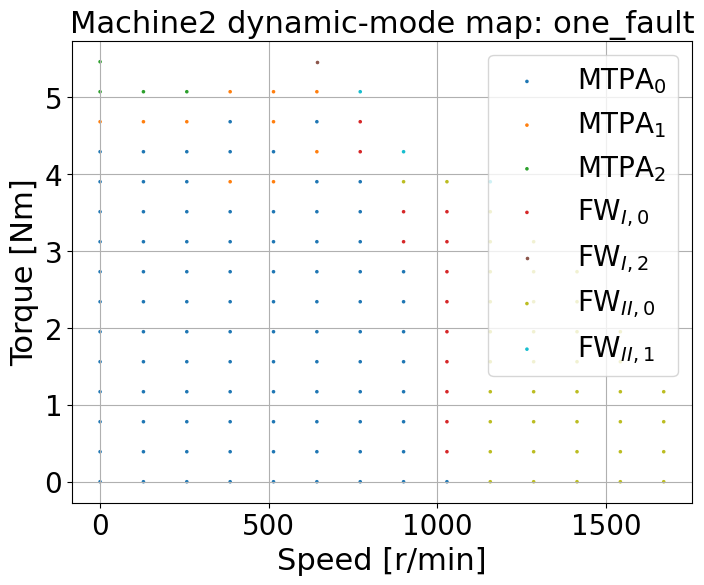

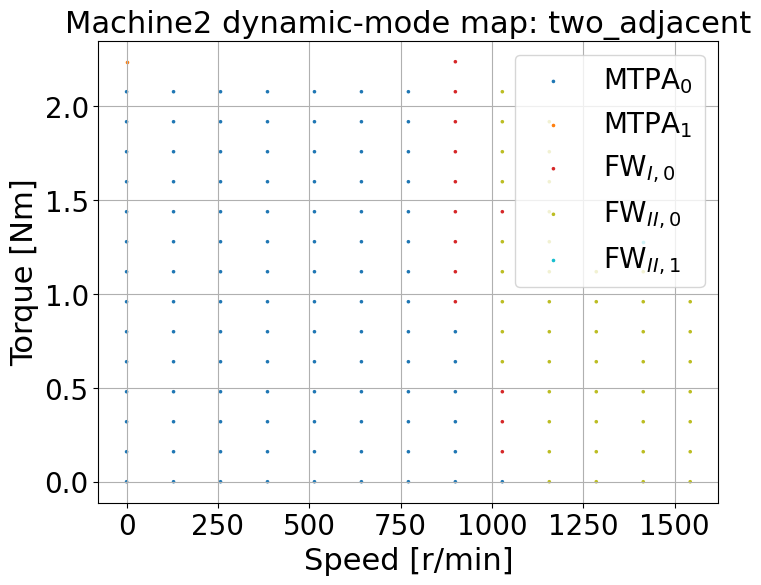

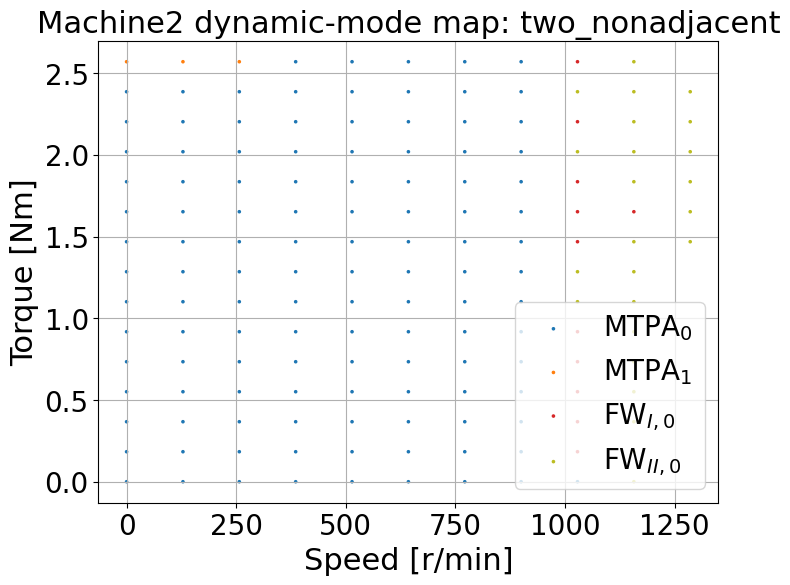

In [4]:
for name, grid in grids.items():
    data = grid_to_data(grid, k_skip=1)
    plot_grid_segments(data, title=f"Machine2 dynamic-mode map: {name}")

In [5]:
from scipy.optimize import minimize as _minimize

from current_setpoints.models.forward_model import _build_clarke_5phase, count_peaks_at_limit

# Fall et al. (2016) formulation: only (id1, iq1) are free/optimized constants.
# (id3, iq3) are NOT an independent search dimension at all -- they are a
# theta-VARYING "consequence" (paper Section 3.4) forced by two physical
# requirements at every instant: (a) the surviving phases' harmonic-1
# projection must equal the target (id1, iq1), and (b) the wye connection's
# zero-sum constraint (sum of surviving phase currents = 0). This is a
# genuinely different reconstruction from this codebase's own reduced map
# (which uses harmonic-1 AND harmonic-2 rows, with no zero-sum requirement
# at all) -- not just a restriction of it, so it needs its own linear solve,
# built here generically from _build_clarke_5phase() rather than hardcoded to
# the paper's specific worked examples (phase 'a'; 'a,b'; 'a,c').
#
# For a 2-open-phase fault this system is exactly determined (3 equations --
# 2 harmonic-1 + 1 zero-sum -- for the 3 surviving-phase unknowns), matching
# the paper's closed form (Eqs. 26-30 adjacent, 35-38 non-adjacent) exactly.
# For healthy/1-open-phase it's underdetermined by one degree of freedom (3
# equations, 5 or 4 unknowns); the paper closes healthy mode the same way
# (id3=iq3=0, Section 3.1) and 1-fault with an extra "equal current
# magnitude" assumption derived symbolically for one specific open phase
# (Eqs. 16-19). The minimum-norm (pseudo-inverse) solution used here is a
# standard, closely-related substitute for that extra assumption -- it also
# favors balanced surviving currents -- and generalizes to any open phase
# without a fresh per-case symbolic derivation; verified to reproduce
# id3=iq3=0 automatically in healthy mode (the harmonic-1/2/zero-sequence
# rows of the static Clarke matrix are mutually orthogonal over all 5
# phases, so minimum-norm naturally avoids exciting the unconstrained
# harmonic-2 direction there).
_C_FULL = _build_clarke_5phase()


def fall_full_trajectory(kept, id1, iq1, theta_arr):
    """Returns (i_full_5phase (n_t,5), i_dq_traj (n_t,4)) for constant
    (id1, iq1) over the given theta samples, per the derivation above."""
    kept = list(kept)
    A = _C_FULL[[0, 1, 4], :][:, kept]  # (3, n_kept): h1_d, h1_q, zero-seq rows
    A_pinv = np.linalg.pinv(A)
    c1, s1 = np.cos(theta_arr), np.sin(theta_arr)
    target = np.stack([c1 * id1 - s1 * iq1, s1 * id1 + c1 * iq1, np.zeros_like(theta_arr)], axis=-1)
    i_kept = np.einsum("ij,tj->ti", A_pinv, target)  # (n_t, n_kept)

    i_full = np.zeros((theta_arr.size, 5))
    for idx, p in enumerate(kept):
        i_full[:, p] = i_kept[:, idx]

    raw_h2 = i_full @ _C_FULL[2:4, :].T  # (n_t, 2) -- forward harmonic-2 projection
    c3, s3 = np.cos(3 * theta_arr), np.sin(3 * theta_arr)
    id3 = c3 * raw_h2[:, 0] + s3 * raw_h2[:, 1]
    iq3 = -s3 * raw_h2[:, 0] + c3 * raw_h2[:, 1]

    i_dq_traj = np.stack([np.full(theta_arr.size, id1), np.full(theta_arr.size, iq1), id3, iq3], axis=-1)
    return i_full, i_dq_traj


def fall_voltage_waveform(fwd, kept, omega, theta_grid, i_dq_traj):
    """Phase voltage waveform (n_kept, n_grid) for the given i_dq trajectory,
    including the inductive d/dtheta term (forward difference, matching
    ActiveSetOptimizer's own scheme) -- exact for the trajectory case, unlike
    ForwardModel.volt_ph which assumes a theta-independent constant current."""
    n_theta_fine = fwd.vec_theta.size - 1
    idx_grid = np.round(theta_grid / (2 * np.pi) * n_theta_fine).astype(int) % n_theta_fine
    dtheta = theta_grid[1] - theta_grid[0]
    didtheta = (np.roll(i_dq_traj, -1, axis=0) - i_dq_traj) / dtheta
    v_wave = np.zeros((len(kept), theta_grid.size))
    for n, idx in enumerate(idx_grid):
        gU, gL, bV = fwd.volt_map_at_theta(int(idx), omega, i_dq_traj[n])
        v_ph = gU @ i_dq_traj[n] + omega * (gL @ didtheta[n]) + bV
        v_wave[:, n] = v_ph[kept]
    return v_wave


def _fall_solve(fwd, kept, theta_grid, omega, torq_target, x0):
    curr_max, volt_max = fwd.drive.curr_max, fwd.drive.volt_max

    def torque_traj(x):
        _, i_dq_traj = fall_full_trajectory(kept, x[0], x[1], theta_grid)
        return np.array([fwd.drive.torque(omega, i_dq_traj[n]) for n in range(theta_grid.size)]), i_dq_traj

    def curr_con(x):
        i_full, _ = fall_full_trajectory(kept, x[0], x[1], theta_grid)
        return curr_max - np.max(np.abs(i_full[:, kept]))

    def volt_con(x):
        _, i_dq_traj = fall_full_trajectory(kept, x[0], x[1], theta_grid)
        v_wave = fall_voltage_waveform(fwd, kept, omega, theta_grid, i_dq_traj)
        return volt_max - np.max(np.abs(v_wave))

    cons = [{"type": "ineq", "fun": curr_con}, {"type": "ineq", "fun": volt_con}]
    if torq_target is None:
        obj = lambda x: -np.min(torque_traj(x)[0])  # worst-angle envelope, matching dynamic-mode convention
    else:
        cons.append({"type": "eq", "fun": lambda x, T=torq_target: float(np.min(torque_traj(x)[0]) - T)})
        obj = lambda x: float(x[0] ** 2 + x[1] ** 2)

    seeds = [x0, np.zeros(2), np.array([curr_max * 0.5, 0.0]), np.array([0.0, curr_max * 0.5])]
    best = None
    for seed in seeds:
        res = _minimize(
            obj, seed, method="SLSQP", constraints=cons,
            bounds=[(-2 * curr_max, 2 * curr_max)] * 2,
            options={"ftol": 1e-8, "maxiter": 300},
        )
        if res.success and (best is None or res.fun < best.fun):
            best = res
    return best


def compute_fall_grid(fwd, opts, n_grid=60):
    drive = fwd.drive
    kept = list(fwd.fault._kept)
    theta_grid = np.linspace(0.0, 2 * np.pi, n_grid, endpoint=False)
    const_mech_speed = 30.0 / (np.pi * drive.n_ppairs)

    probe = _fall_solve(fwd, kept, theta_grid, 0.0, None, np.zeros(2))
    if probe is None:
        raise RuntimeError("Fall-mode T_max probe at omega=0 failed.")
    torq_max_global = -probe.fun

    n_torq, n_omega = opts["n_torq"], opts["n_omega"]
    grid = {
        "const_mech_speed": const_mech_speed,
        "vec_torq": np.linspace(opts["torq_min"], torq_max_global, n_torq),
        "vec_omega": np.linspace(
            opts["omega_min"] / const_mech_speed, float(opts["omega_max"]) / const_mech_speed, n_omega
        ),
        "vec_torq_max": np.full((1, n_omega), np.nan),
        "grid_curr_peak": np.full((n_torq, n_omega), np.nan),
        "grid_volt_peak": np.full((n_torq, n_omega), np.nan),
        "grid_segments": np.full((n_torq, n_omega), np.nan),
        "curr_dq_grid": np.full((drive.dim, n_torq, n_omega), np.nan),
    }

    print(f"Starting Fall-mode grid: {n_torq} torques x {n_omega} speeds")
    prev_max_x = np.zeros(2)
    for idx_omega in range(n_omega):
        omega = float(grid["vec_omega"][idx_omega])
        print(f"  Speed {idx_omega + 1}/{n_omega}: {omega * const_mech_speed:.1f} RPM")

        sol_max = _fall_solve(fwd, kept, theta_grid, omega, None, prev_max_x)
        torq_max_local = -sol_max.fun if sol_max is not None else torq_max_global
        if sol_max is not None:
            prev_max_x = sol_max.x
        grid["vec_torq_max"][0, idx_omega] = torq_max_local

        prev_x = np.zeros(2)
        for idx_torq in range(n_torq):
            torq_target = float(grid["vec_torq"][idx_torq])
            if torq_target > min(torq_max_local, torq_max_global):
                break
            sol = _fall_solve(fwd, kept, theta_grid, omega, torq_target, prev_x)
            if sol is None:
                continue
            prev_x = sol.x
            i_full, i_dq_traj = fall_full_trajectory(kept, sol.x[0], sol.x[1], theta_grid)

            curr_wave = i_full[:, kept].T  # (n_kept, n_grid)
            v_wave = fall_voltage_waveform(fwd, kept, omega, theta_grid, i_dq_traj)
            curr_wrapped = np.concatenate([curr_wave, curr_wave[:, :1]], axis=1)
            v_wrapped = np.concatenate([v_wave, v_wave[:, :1]], axis=1)

            grid["grid_curr_peak"][idx_torq, idx_omega] = float(np.max(np.abs(curr_wave)))
            grid["grid_volt_peak"][idx_torq, idx_omega] = float(np.max(np.abs(v_wave)))
            n_curr = count_peaks_at_limit(curr_wrapped, drive.curr_max)
            n_volt = count_peaks_at_limit(v_wrapped, drive.volt_max)
            grid["grid_segments"][idx_torq, idx_omega] = 3 * n_volt + n_curr
            grid["curr_dq_grid"][:, idx_torq, idx_omega] = np.mean(i_dq_traj, axis=0)

    print("Fall-mode grid complete.")
    return grid


grids_fall = {}
for name, open_phases in SCENARIOS.items():
    pkl_path = os.path.join(data_dir, f"fault_map_fall_{name}.pkl")

    if os.path.isfile(pkl_path):
        with open(pkl_path, "rb") as f:
            grids_fall[name] = pickle.load(f)
        continue

    drive = ieee_machine2_trained_neural_flux(curr_max=CURR_MAX, volt_max=VOLT_MAX)
    fwd = ForwardModel(drive, n_theta=700, fault=Fault(open_phases))

    grid = compute_fall_grid(fwd, GRID_OPTS, n_grid=N_GRID)
    with open(pkl_path, "wb") as f:
        pickle.dump(grid, f)
    grids_fall[name] = grid

Starting Fall-mode grid: 15 torques x 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Fall-mode grid complete.
Starting Fall-mode grid: 15 torques x 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Fall-mode grid complete.
Starting Fall-mode grid: 15 torques x 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.

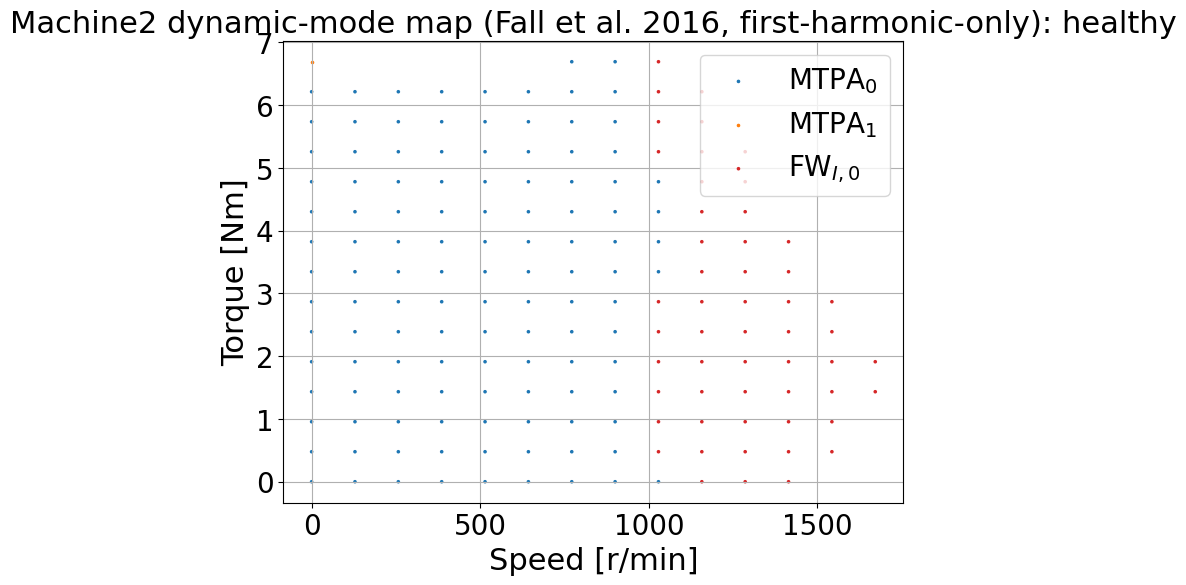

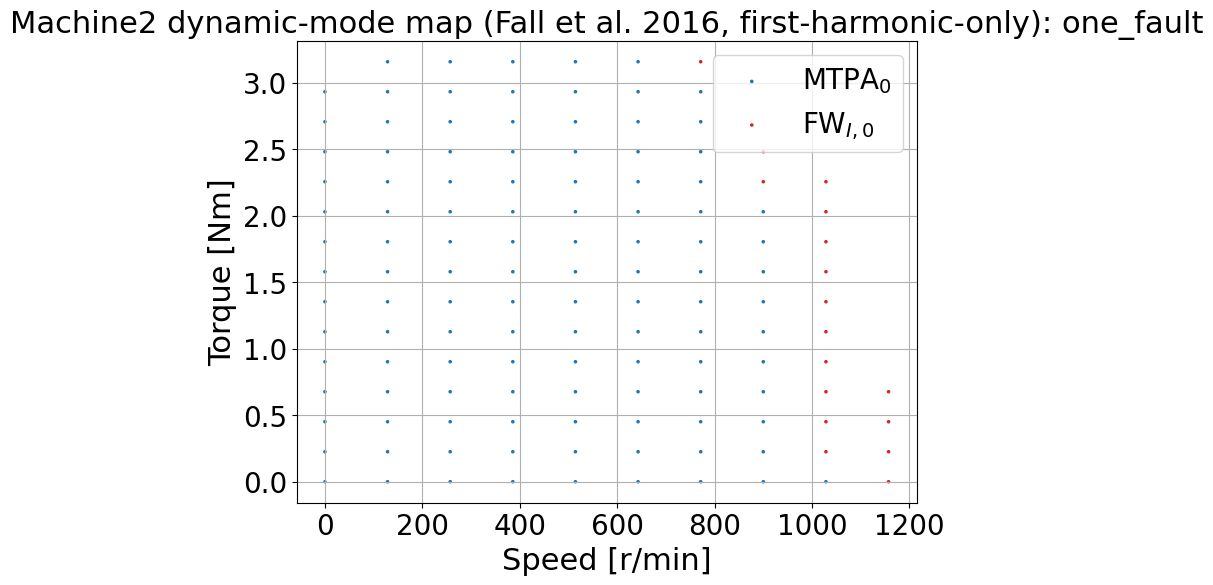

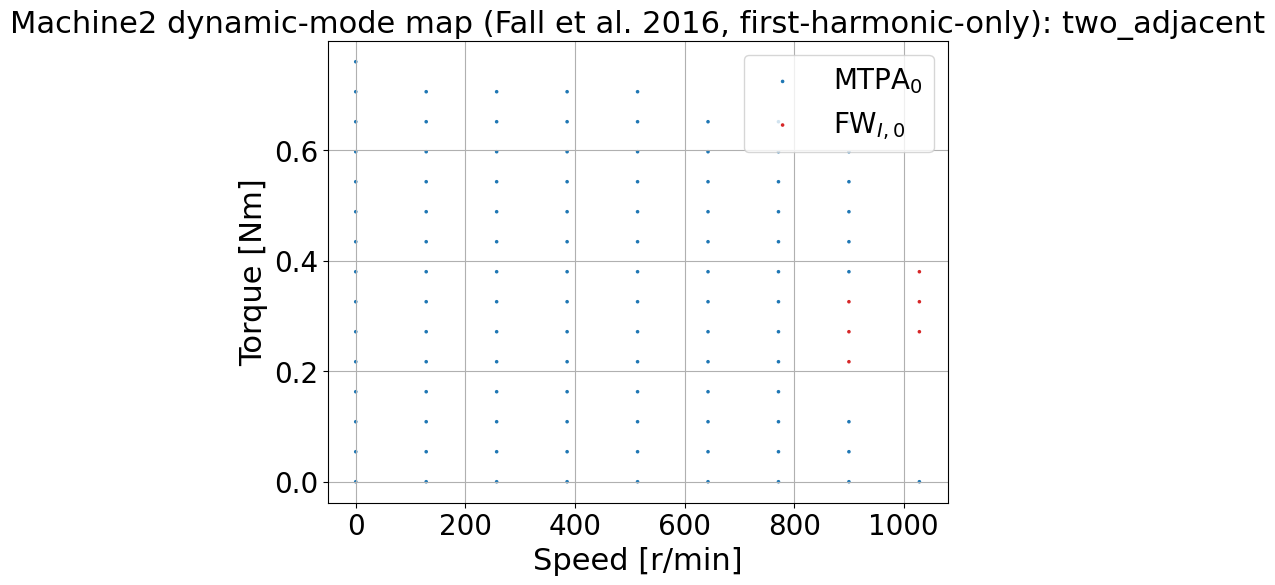

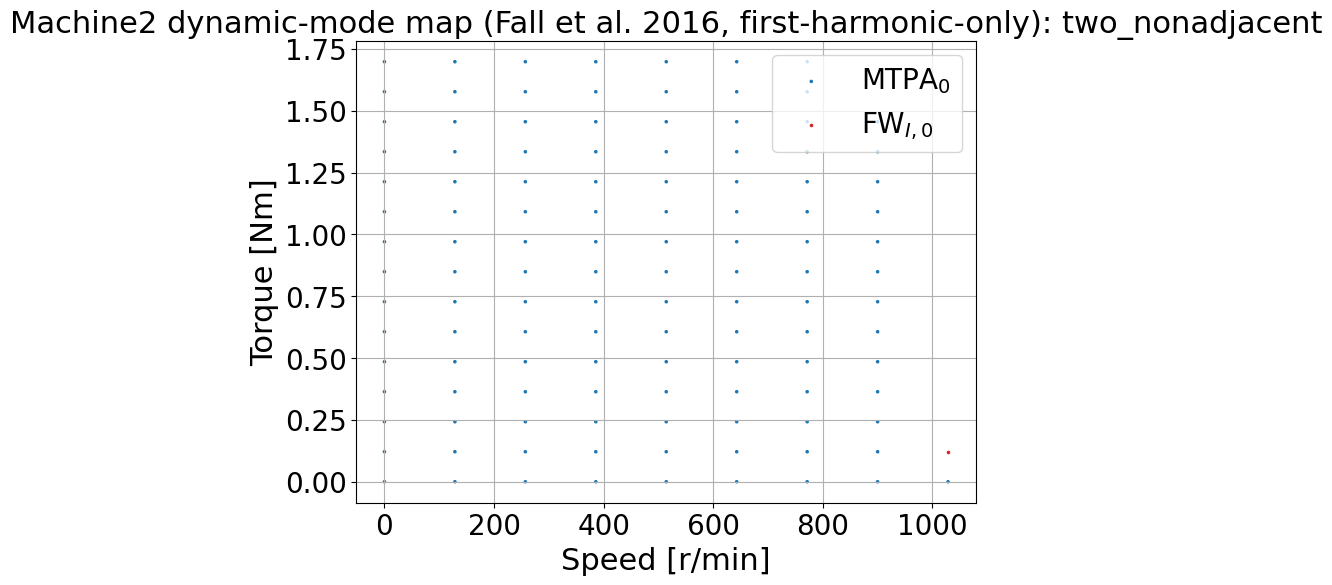

In [6]:
for name, grid in grids_fall.items():
    data = grid_to_data(grid, k_skip=1)
    plot_grid_segments(data, title=f"Machine2 dynamic-mode map (Fall et al. 2016, first-harmonic-only): {name}")